# <p style="background-color:#FF5722; font-family:'Pacifico', cursive; color:#FFFFFF; font-size:140%; text-align:center; border: 1px double #FFEB3B; border-radius:15px; padding: 15px; box-shadow: 3px 3px 15px rgba(0, 0, 0, 0.5); font-weight: bold; letter-spacing: 1px;">Exploring Mental Health | Starter</p>

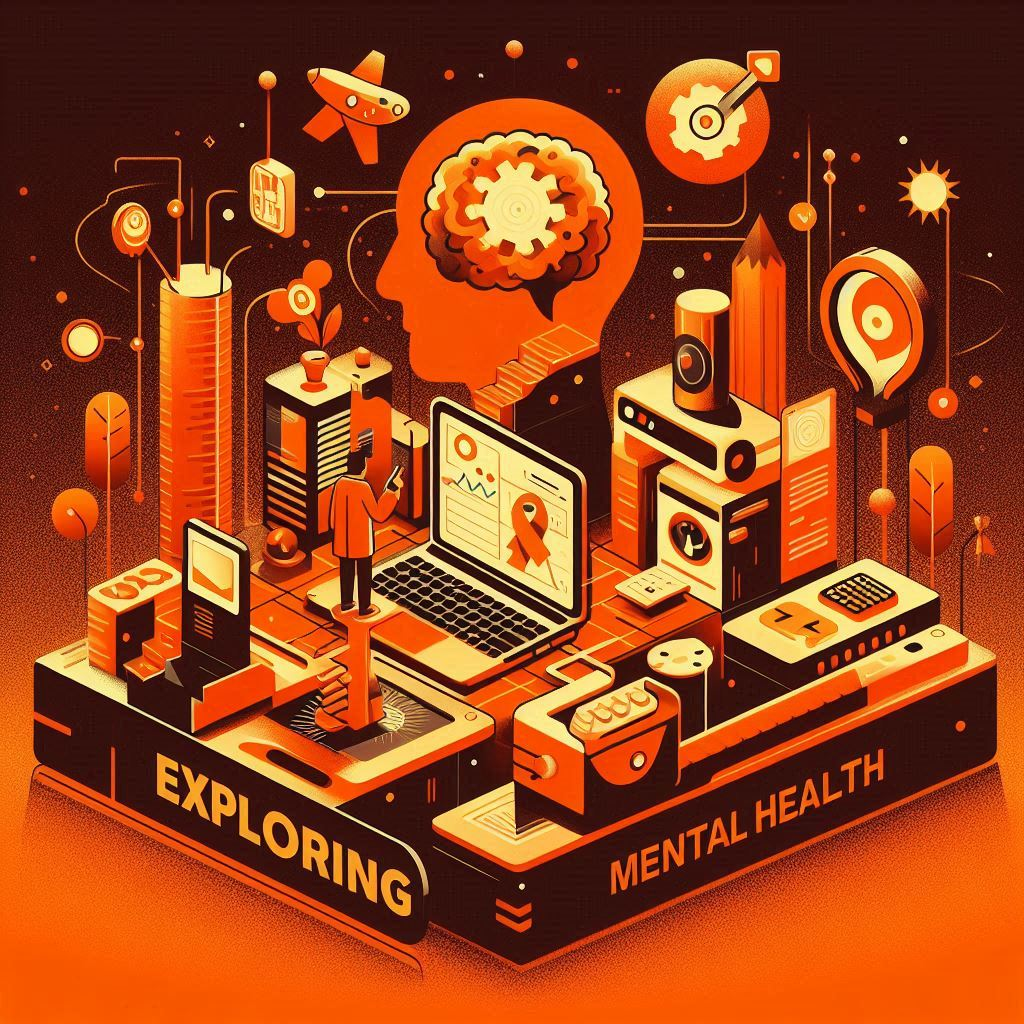

# <p style="background-color:#FF5722; font-family:'Pacifico', cursive; color:#FFFFFF; font-size:120%; text-align:center; border: 1px double #FFEB3B; border-radius:15px; padding: 15px; box-shadow: 3px 3px 15px rgba(0, 0, 0, 0.5); font-weight: bold; letter-spacing: 1px;">Imports</p>

In [1]:
import numpy as np

import polars as pl

import pandas as pd

from sklearn.base import clone

import optuna

import os

import category_encoders as ce

from IPython.display import clear_output

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.graph_objects as go

import plotly.express as px

import warnings

warnings.filterwarnings('ignore')

pd.options.display.max_columns = None

sns.set_palette("YlOrBr")



import lightgbm as lgb

from catboost import CatBoostRegressor, CatBoostClassifier, Pool

from sklearn.model_selection import *

from sklearn.metrics import *

# Create a custom palette using the new colors

custom_palette = sns.color_palette(["#38110c", "#f0580c", "#f2cd76", "#6e2716", "#b5441d"])

# Set the custom palette

sns.set_palette(custom_palette)


# <p style="background-color:#FF5722; font-family:'Pacifico', cursive; color:#FFFFFF; font-size:120%; text-align:center; border: 1px double #FFEB3B; border-radius:15px; padding: 15px; box-shadow: 3px 3px 15px rgba(0, 0, 0, 0.5); font-weight: bold; letter-spacing: 1px;">Load Data</p>

In [2]:
%%time



!git clone https://github.com/muhammadabdullah0303/AbdML



import sys

sys.path.append('/kaggle/working/repository')



from AbdML.main import AbdBase



train = pd.read_csv('/kaggle/input/playground-series-s4e11/train.csv')

test = pd.read_csv('/kaggle/input/playground-series-s4e11/test.csv')

sample = pd.read_csv('/kaggle/input/playground-series-s4e11/sample_submission.csv')

original = pd.read_csv('/kaggle/input/depression-surveydataset-for-analysis/final_depression_dataset_1.csv')



original['Depression'] = original['Depression'].map({

    'No': 0,

    'Yes': 1

})



train = train.drop('id',axis=1)

test = test.drop('id',axis=1)



train = pd.concat(objs=[train, original])



cat_c = ['Name', 'Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration',

 'Dietary Habits','Degree','Have you ever had suicidal thoughts ?','Family History of Mental Illness']



def update(df):

    global cat_c



    for col in cat_c:

        

        df[col] = df[col].fillna('missing')

        df[col] = df[col].astype('category')

        

    return df 

    

train = update(train)

test = update(test)

Cloning into 'AbdML'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 101 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 38.36 KiB | 1.42 MiB/s, done.
Resolving deltas: 100% (32/32), done.
CPU times: user 1.18 s, sys: 101 ms, total: 1.28 s
Wall time: 2.95 s


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143256 entries, 0 to 2555
Data columns (total 19 columns):
 #   Column                                 Non-Null Count   Dtype   
---  ------                                 --------------   -----   
 0   Name                                   143256 non-null  category
 1   Gender                                 143256 non-null  category
 2   Age                                    143256 non-null  float64 
 3   City                                   143256 non-null  category
 4   Working Professional or Student        143256 non-null  category
 5   Profession                             143256 non-null  category
 6   Academic Pressure                      28399 non-null   float64 
 7   Work Pressure                          114836 non-null  float64 
 8   CGPA                                   28400 non-null   float64 
 9   Study Satisfaction                     28399 non-null   float64 
 10  Job Satisfaction                       114844 non-n

In [4]:
import plotly.graph_objects as go

import plotly.express as px



custom_palette = ["#38110c", "#f0580c", "#f2cd76", "#6e2716", "#b5441d"]

depression_counts = train['Depression'].value_counts()



# Donut Plot

go.Figure(go.Pie(labels=depression_counts.index, values=depression_counts.values, hole=0.4, marker=dict(colors=custom_palette), textinfo='percent+label')).update_layout(title="Distribution of Depression Cases (Donut Plot)").show()



# Bar Plot

px.bar(train, x='Depression', color='Depression', color_discrete_sequence=custom_palette, title="Distribution of Depression Cases (Bar Plot)").update_layout(xaxis_title="Depression (1 = Yes, 0 = No)", yaxis_title="Count").show()


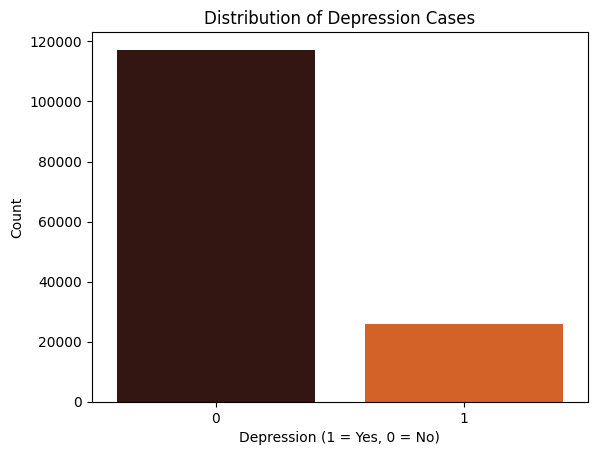

In [5]:
sns.countplot(data=train, x='Depression', palette=custom_palette).set(title="Distribution of Depression Cases",

                                                                xlabel="Depression (1 = Yes, 0 = No)", ylabel="Count")

plt.show()




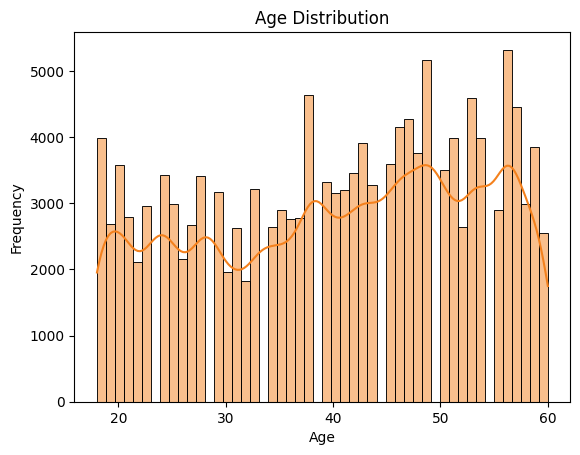

In [6]:
sns.histplot(train['Age'], kde=True, color=sns.color_palette("YlOrBr")[3]).set(title="Age Distribution",

                                                                               xlabel="Age", ylabel="Frequency")

plt.show()

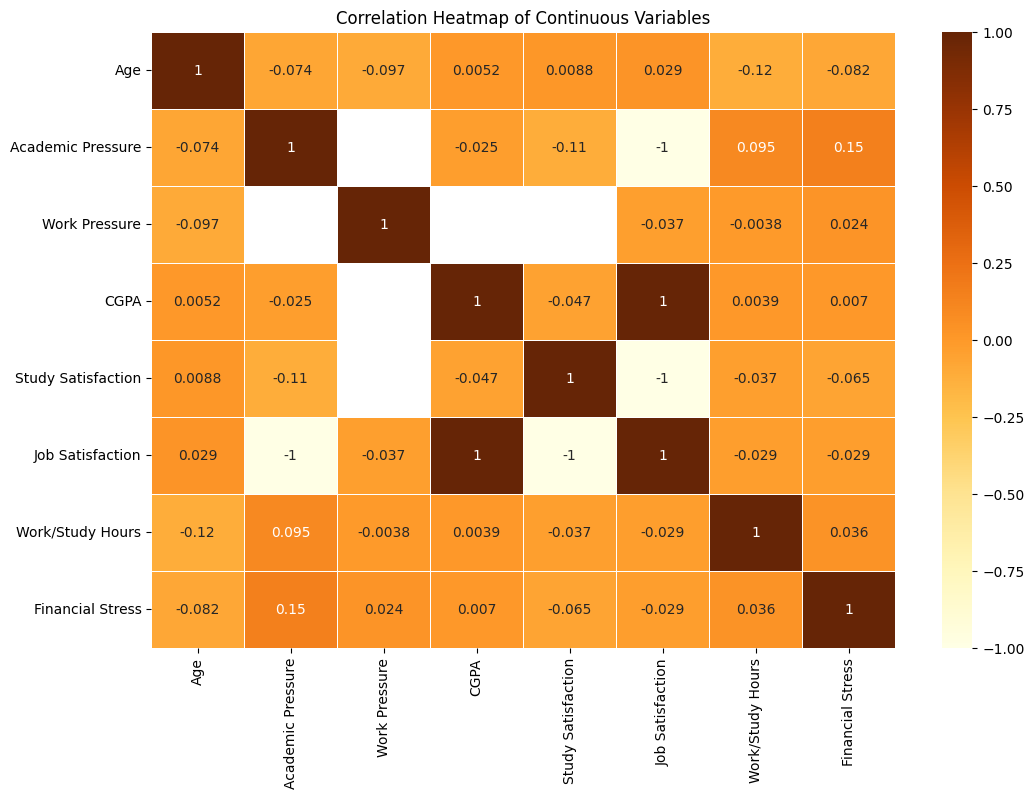

In [7]:
# Correlation heatmap for numeric features

numeric_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 

                'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

plt.figure(figsize=(12, 8))

sns.heatmap(train[numeric_cols].corr(), annot=True, cmap="YlOrBr", linewidths=0.5)

plt.title("Correlation Heatmap of Continuous Variables")

plt.show()


## Insights from Correlation Heatmap



1. **Key Negative Correlations**:

   - **Academic Pressure** and **Job Satisfaction**: Strong inverse relationship (-1), suggesting higher academic pressure significantly decreases job satisfaction.

   - **Age** and **Work/Study Hours**: Moderate negative correlation (-0.12), indicating older individuals may spend fewer hours on work/study.



2. **Notable Positive Correlations**:

   - **Academic Pressure** and **Financial Stress**: Positive correlation (0.15), implying that higher academic pressure may contribute to financial stress.

   - **Work/Study Hours** and **Academic Pressure**: Positive correlation (0.095), suggesting longer work/study hours are associated with increased academic pressure.



3. **Minimal Correlation with CGPA**:

   - CGPA shows low correlation with other factors, indicating that academic performance is not strongly influenced by satisfaction or stress levels.



- The heatmap highlights significant interactions, especially how **academic pressure** impacts both **job satisfaction** and **financial stress**. Conversely, **CGPA** and **Work Pressure** show limited relationships with other variables.

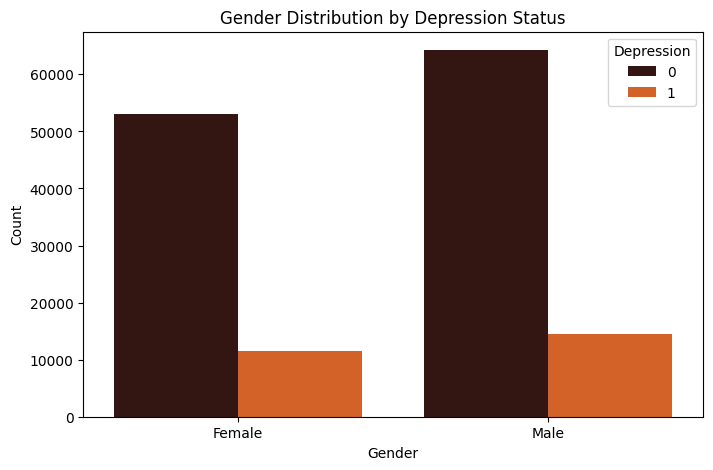

In [8]:
# Count plot for Gender and Depression

plt.figure(figsize=(8, 5))

sns.countplot(data=train, x='Gender', hue='Depression', palette=custom_palette)

plt.title("Gender Distribution by Depression Status")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.legend(title="Depression")

plt.show()


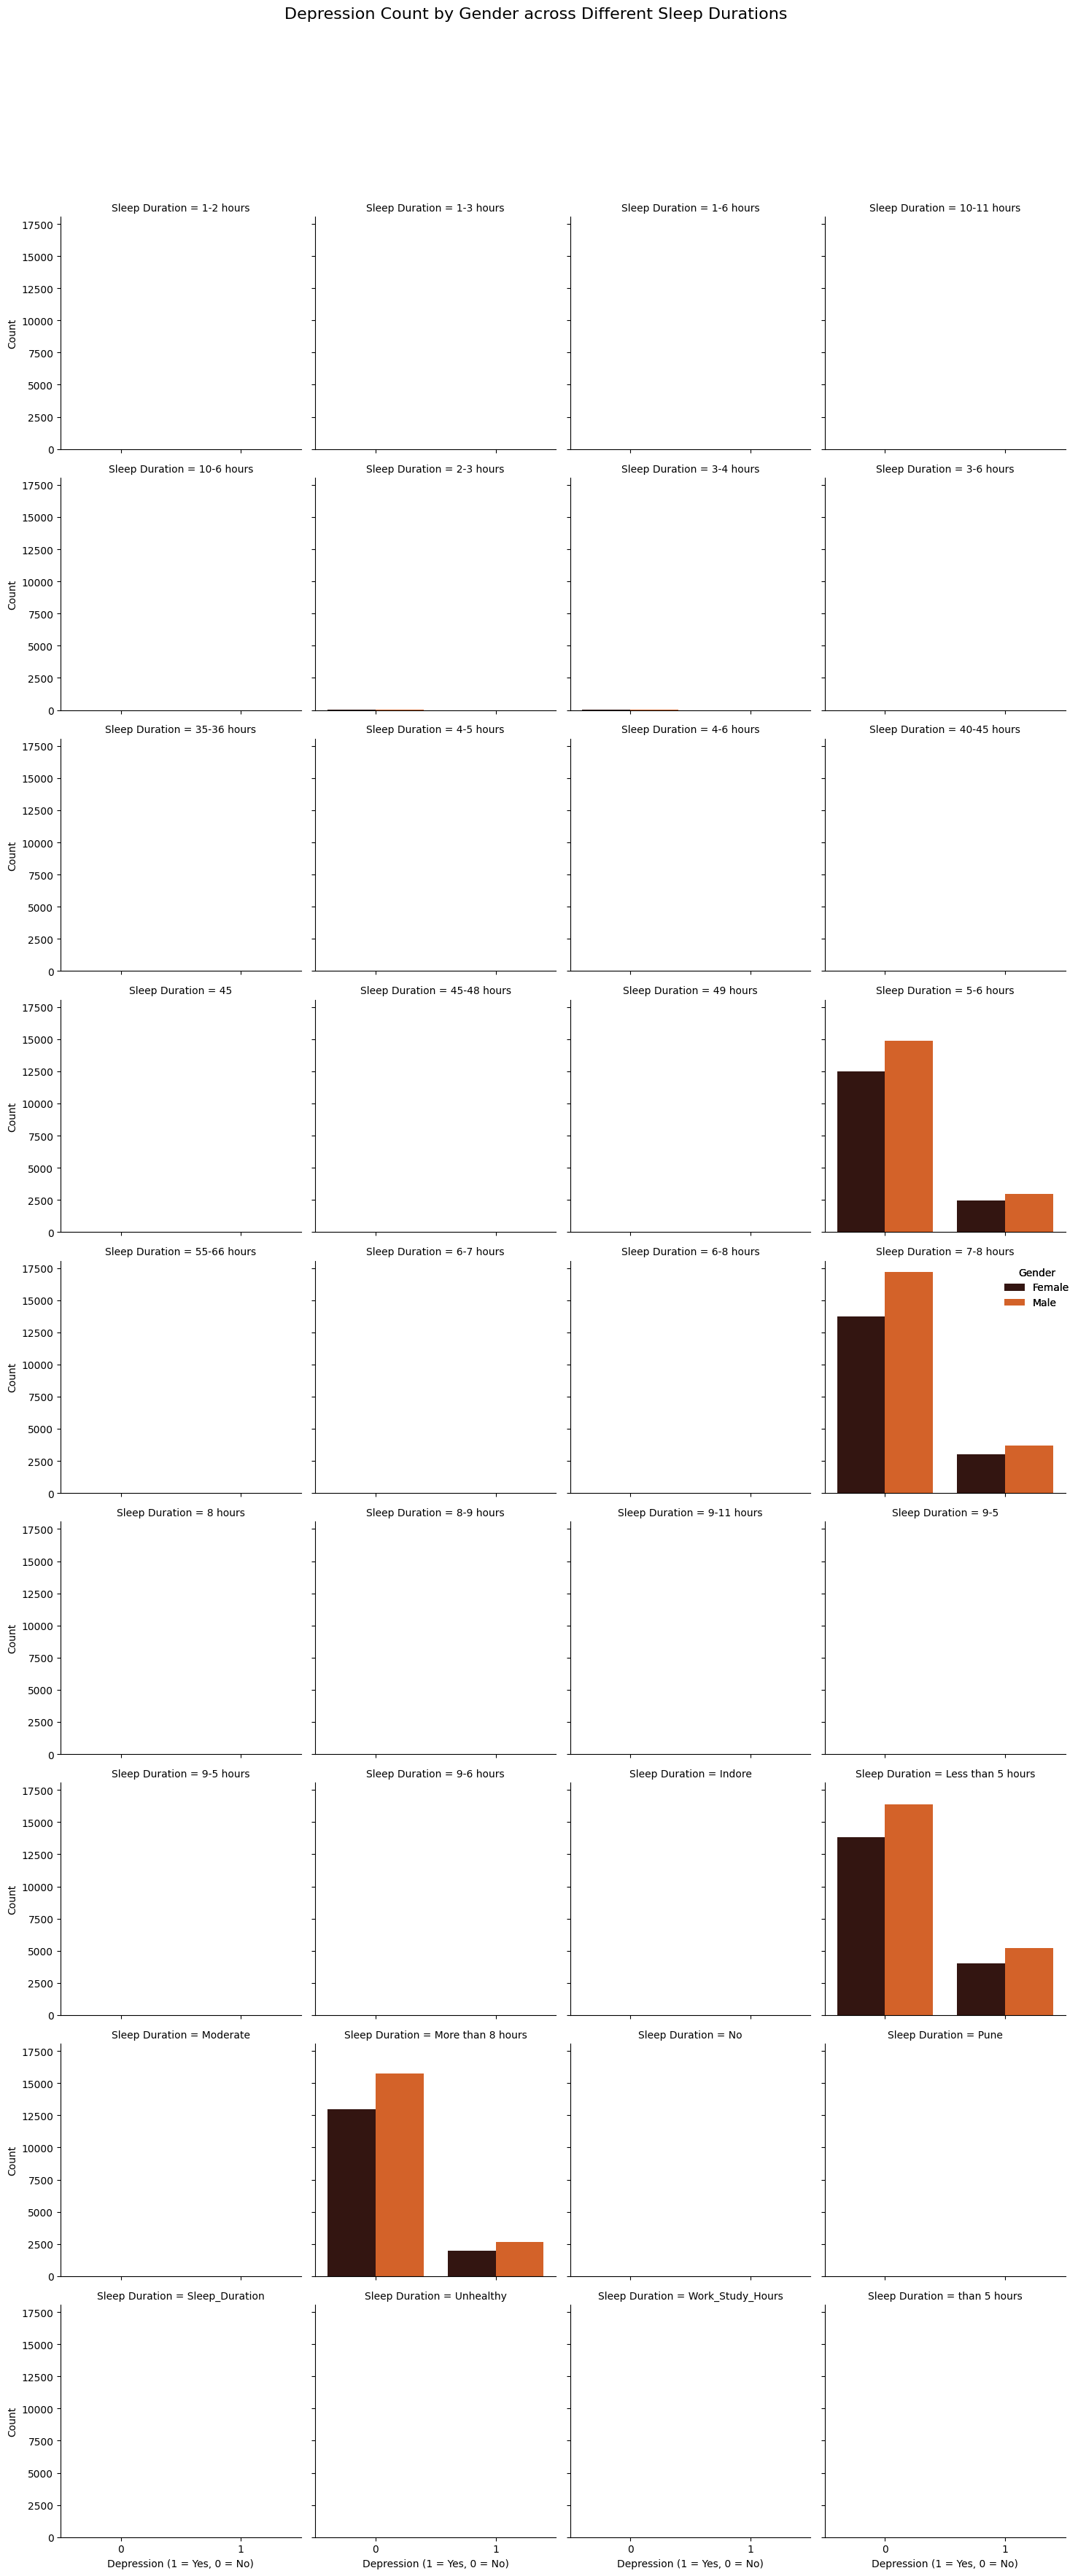

In [9]:
# Create a facet grid with 'Gender' and 'Sleep Duration' as rows and columns

g = sns.catplot(data=train, x='Depression', kind='count', hue='Gender', col='Sleep Duration', 

                palette=custom_palette, height=4, aspect=0.8, col_wrap=4)



# Adjust plot title and labels for clarity

g.fig.suptitle("Depression Count by Gender across Different Sleep Durations", fontsize=16)

g.set_axis_labels("Depression (1 = Yes, 0 = No)", "Count")

g.add_legend(title="Gender")

plt.tight_layout()

plt.subplots_adjust(top=0.9)

plt.show()

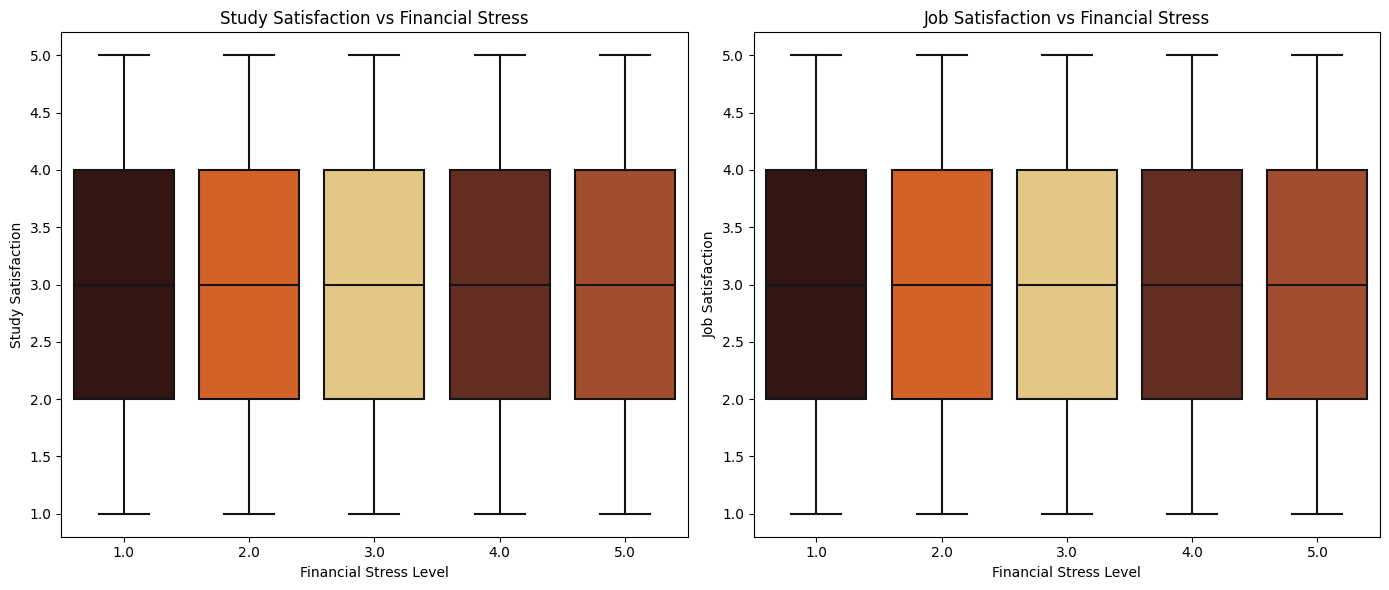

In [10]:
plt.figure(figsize=(14, 6))



# Plot for Study Satisfaction

plt.subplot(1, 2, 1)

sns.boxplot(data=train, x='Financial Stress', y='Study Satisfaction', palette=custom_palette)

plt.title("Study Satisfaction vs Financial Stress")

plt.xlabel("Financial Stress Level")

plt.ylabel("Study Satisfaction")



# Plot for Job Satisfaction

plt.subplot(1, 2, 2)

sns.boxplot(data=train, x='Financial Stress', y='Job Satisfaction', palette=custom_palette)

plt.title("Job Satisfaction vs Financial Stress")

plt.xlabel("Financial Stress Level")

plt.ylabel("Job Satisfaction")



plt.tight_layout()

plt.show()


## Insights from Study & Job Satisfaction vs Financial Stress



1. **Study Satisfaction**:

   - Study satisfaction is relatively stable across financial stress levels (1 to 5).

   - Median satisfaction scores hover around **3.0–3.5** with no major variation, indicating that financial stress has minimal impact on study satisfaction.



2. **Job Satisfaction**:

   - Job satisfaction also remains stable across financial stress levels, with median scores around **3.0–3.5**.

   - Similar to study satisfaction, financial stress shows limited impact on job satisfa#- # Summary

Both study and job satisfaction levels are **relatively unaffected by financial stress**. Satisfaction levels across different financial stress levels remain consistent, suggesting that other factors may play a more significant role in influencing satisfaction in these areas.


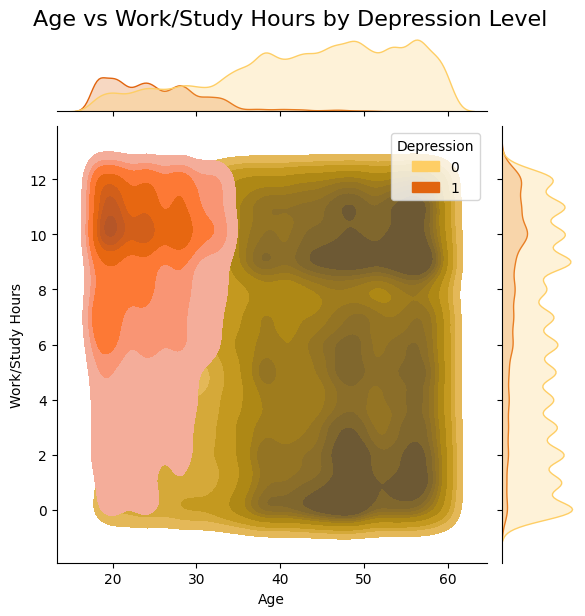

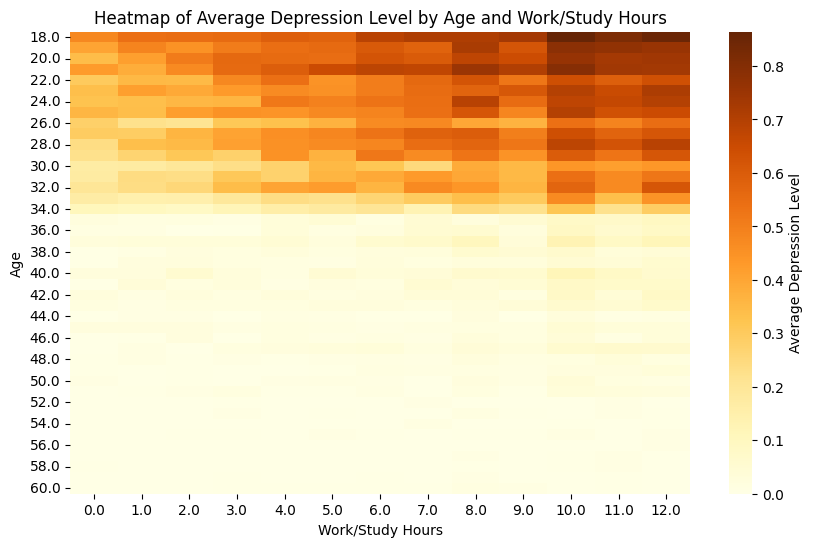

In [11]:
# Plot with regression and KDE for density

sns.jointplot(data=train, x='Age', y='Work/Study Hours', hue='Depression', kind="kde", palette="YlOrBr", fill=True)

plt.suptitle("Age vs Work/Study Hours by Depression Level", y=1.02, fontsize=16)

plt.xlabel("Age")

plt.ylabel("Work/Study Hours")

plt.show()



# Calculate the average depression level for each Age and Work/Study Hours combination

age_hours_pivot = train.pivot_table(values='Depression', index='Age', columns='Work/Study Hours', aggfunc='mean')



plt.figure(figsize=(10, 6))

sns.heatmap(age_hours_pivot, cmap="YlOrBr", annot=False, cbar_kws={'label': 'Average Depression Level'})

plt.title("Heatmap of Average Depression Level by Age and Work/Study Hours")

plt.xlabel("Work/Study Hours")

plt.ylabel("Age")

plt.show()

## Insights from Age vs Work/Study Hours by Depression Level


1. **Depression in Younger Age Groups**:

   - High concentration of depression (red/pink zones) is seen in younger individuals (ages 18–25), especially those working/studying **6–12 hours/day**.



2. **Lower Depression in Middle-Aged and Older Groups**:

   - For those over 30, depression levels are lower (yellow/brown zones), with work/study hours spread more evenly.



3. **Work/Study Hours and Depression**:

   - Younger individuals with longer work/study hours are more associated with depression. Older age groups show a wider distribution in work/study hours with less correlation to de pressures.


In [12]:
train.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,Yuvraj,Male,33.0,Visakhapatnam,Student,missing,5.0,NaN,8.97,2.0,NaN,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,NaN,5.0,NaN,NaN,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,NaN,1.0,NaN,NaN,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [13]:
test.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No
2,Yash,Male,53.0,Jaipur,Working Professional,Teacher,NaN,4.0,NaN,NaN,1.0,7-8 hours,Moderate,B.Arch,Yes,12.0,4.0,No
3,Nalini,Female,23.0,Rajkot,Student,missing,5.0,NaN,6.84,1.0,NaN,More than 8 hours,Moderate,BSc,Yes,10.0,4.0,No
4,Shaurya,Male,47.0,Kalyan,Working Professional,Teacher,NaN,5.0,NaN,NaN,5.0,7-8 hours,Moderate,BCA,Yes,3.0,4.0,No


# <p style="background-color:#FF5722; font-family:'Pacifico', cursive; color:#FFFFFF; font-size:120%; text-align:center; border: 1px double #FFEB3B; border-radius:15px; padding: 15px; box-shadow: 3px 3px 15px rgba(0, 0, 0, 0.5); font-weight: bold; letter-spacing: 1px;">Modeling</p>

In [14]:
%%time



SEED = 42



base = AbdBase(train_data=train, test_data=test, target_column='Depression',

                 problem_type="classification", metric="accuracy", seed=SEED,test_prob="True",

                 n_splits=5,early_stop=None,prob=False,num_classes=2,fold_type='SKF',cat_features=None)



Params = {'n_estimators': 1831, 'learning_rate': 0.02346836833641594, 'max_depth': 9, 'reg_alpha': 6.922625567886367,

          'reg_lambda': 0.056362059064680975, 'num_leaves': 494, 'subsample': 0.6100765233477121, 

          'colsample_bytree': 0.12961396327401215, 'verbosity':-1, 'device':'gpu'} # 0.9408 "LB : 0.94275"



meanOFF, meanTest = base.Train_ML(Params,'LGBM')

Training Folds: 100%|██████████| 5/5 [03:16<00:00, 39.39s/it]

Overall Train ACCURACY: 0.9468
Overall OOF ACCURACY: 0.9408
CPU times: user 6min 30s, sys: 2.44 s, total: 6min 33s
Wall time: 3min 16s


# <p style="background-color:#FF5722; font-family:'Pacifico', cursive; color:#FFFFFF; font-size:120%; text-align:center; border: 1px double #FFEB3B; border-radius:15px; padding: 15px; box-shadow: 3px 3px 15px rgba(0, 0, 0, 0.5); font-weight: bold; letter-spacing: 1px;">Submission</p>

In [15]:
%%time



sample['Depression'] = np.where(meanTest >= 0.5, 1, 0)



sample.to_csv('submission_Ens.csv', index=False)



sample.head()

CPU times: user 218 ms, sys: 7.02 ms, total: 225 ms
Wall time: 112 ms


,id,Depression
0,140700,0
1,140701,0
2,140702,0
3,140703,1
4,140704,0
